In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from warnings import filterwarnings
filterwarnings('ignore')
import tensorflow_datasets as fashion_mnist
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier


In [ ]:
# Train
train_fashion_mnist = fashion_mnist.as_numpy(fashion_mnist.load("fashion_mnist", split="train", batch_size=-1))
X_train, y_train = train_fashion_mnist["image"], train_fashion_mnist["label"]

# Test
test_fashion_mnist = fashion_mnist.as_numpy(fashion_mnist.load("fashion_mnist", split="test", batch_size=-1))
X_test, y_test = test_fashion_mnist["image"], test_fashion_mnist["label"]

print("Train Samples:", len(X_train))
print("Test Samples:", len(X_test))

fashion_classes = {0: 'T-shirt/top',
                   1: 'Trouser',
                   2: 'Pullover',
                   3: 'Dress',
                   4: 'Coat',
                   5: 'Sandal',
                   6: 'Shirt',
                   7: 'Sneaker',
                   8: 'Bag',
                   9: 'Ankle boot'}

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...:   0%|          | 0/60000 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/fashion_mnist/incomplete.E3DDQ9_3.0.1/fashion_mnist-train.tfrecord*...:   …

Generating test examples...:   0%|          | 0/10000 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/fashion_mnist/incomplete.E3DDQ9_3.0.1/fashion_mnist-test.tfrecord*...:   0…

Dataset fashion_mnist downloaded and prepared to /root/tensorflow_datasets/fashion_mnist/3.0.1. Subsequent calls will reuse this data.
Train Samples: 60000
Test Samples: 10000


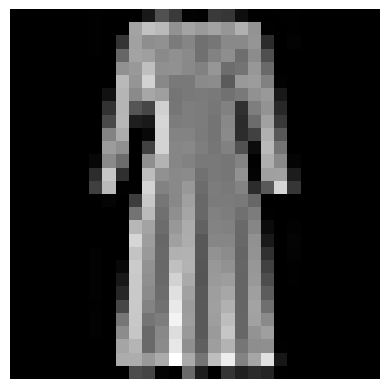

Target: Dress


In [ ]:
idx = np.random.randint(len(X_train))
plt.imshow(np.squeeze(X_train[idx]), cmap='gray')
plt.axis('off')
plt.show()
print("Target:", fashion_classes[y_train[idx]])



In [ ]:
# Defines the options for augmentation
datagen = ImageDataGenerator(
    rotation_range=10,
    horizontal_flip=True,
    fill_mode='nearest'
)

def preprocess_data(images, use_augmentation=False):
    X = []
    for x_ in images:
        # scaling pixels between 0.0-1.0
        x_ = x_ / 255.
        # data Augmentation without increasing the number of images
        if use_augmentation:
            x_ = next(datagen.flow(x_.reshape(1, 28, 28, 1), batch_size=1))[0]
        X.append(x_)
    return np.array(X)


In [ ]:
X_train_shaped = preprocess_data(X_train, use_augmentation=True).reshape((X_train.shape[0], 28, 28, 1))
y_train_shaped = tf.keras.utils.to_categorical(y_train)
X_test_shaped = preprocess_data(X_test).reshape((X_test.shape[0], 28, 28, 1))
y_test_shaped = tf.keras.utils.to_categorical(y_test)

In [ ]:
# CNN Model
cnn = tf.keras.Sequential()
cnn.add(tf.keras.layers.InputLayer(input_shape=(28,28,1)))
# Normalization
cnn.add(tf.keras.layers.BatchNormalization())
# Conv + Maxpooling
cnn.add(tf.keras.layers.Convolution2D(64, (4, 4), padding='same', activation='relu'))
cnn.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))
# Dropout
cnn.add(tf.keras.layers.Dropout(0.1))
# Conv + Maxpooling
cnn.add(tf.keras.layers.Convolution2D(64, (4, 4), activation='relu'))
cnn.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))
# Dropout
cnn.add(tf.keras.layers.Dropout(0.3))
# Converting 3D feature to 1D feature Vector
cnn.add(tf.keras.layers.Flatten())
# Fully Connected Layer
cnn.add(tf.keras.layers.Dense(256, activation='relu'))
# Dropout
cnn.add(tf.keras.layers.Dropout(0.5))
# Fully Connected Layer
cnn.add(tf.keras.layers.Dense(64, activation='relu'))
# Normalization
cnn.add(tf.keras.layers.BatchNormalization())
cnn.add(tf.keras.layers.Dense(10, activation='softmax'))
cnn.compile(loss='categorical_crossentropy', optimizer=tf.optimizers.Adam(), metrics=['accuracy'])

cnn.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ batch_normalization                  │ (None, 28, 28, 1)           │               4 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 28, 28, 64)          │           1,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          65,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         409,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 493,902 (1.88 MB)

 Trainable params: 493,772 (1.88 MB)

 Non-trainable params: 130 (520.00 B)

In [ ]:
# FNN Model
fnn = tf.keras.Sequential()
fnn.add(tf.keras.layers.InputLayer(input_shape=(28 * 28,)))
# Normalization
fnn.add(tf.keras.layers.BatchNormalization())
# Fully Connected Layer
fnn.add(tf.keras.layers.Dense(512, activation='relu'))
# Dropout
fnn.add(tf.keras.layers.Dropout(0.5))
# Fully Connected Layer
fnn.add(tf.keras.layers.Dense(256, activation='relu'))
# Dropout
fnn.add(tf.keras.layers.Dropout(0.3))
# Fully Connected Layer
fnn.add(tf.keras.layers.Dense(128, activation='relu'))
# Normalization
fnn.add(tf.keras.layers.BatchNormalization())
fnn.add(tf.keras.layers.Dense(10, activation='softmax'))
fnn.compile(loss='categorical_crossentropy', optimizer=tf.optimizers.Adam(), metrics=['accuracy'])

fnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ batch_normalization_2                │ (None, 784)                 │           3,136 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 512)                 │         401,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 571,082 (2.18 MB)

 Trainable params: 569,258 (2.17 MB)

 Non-trainable params: 1,824 (7.12 KB)

In [ ]:
X_train_flat = X_train_shaped.reshape((X_train_shaped.shape[0], 28 * 28))
X_test_flat = X_test_shaped.reshape((X_test_shaped.shape[0], 28 * 28))

In [ ]:
# Split data for training and validation
X_train_, X_val_, y_train_, y_val_ = train_test_split(X_train_shaped, y_train_shaped,
                                                      test_size=0.2, random_state=42)
X_train_flat_, X_val_flat_, y_train_flat_, y_val_flat_ = train_test_split(X_train_flat, y_train_shaped,
                                                                          test_size=0.2, random_state=42)

# Train CNN

In [ ]:
cnn_history = cnn.fit(
    X_train_, y_train_,
    batch_size=250,
    epochs=10,
    verbose=1,
    validation_data=(X_val_, y_val_),
    callbacks=[
        tf.keras.callbacks.ModelCheckpoint("fashion_mnist_cnn.keras", monitor='val_loss', verbose=1, save_best_only=True)
    ]
)


Epoch 1/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 700ms/step - accuracy: 0.6010 - loss: 1.1156
Epoch 1: val_loss improved from inf to 2.31159, saving model to fashion_mnist_cnn.keras
192/192 ━━━━━━━━━━━━━━━━━━━━ 145s 735ms/step - accuracy: 0.6016 - loss: 1.1139 - val_accuracy: 0.1269 - val_loss: 2.3116
Epoch 2/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 660ms/step - accuracy: 0.8198 - loss: 0.4950
Epoch 2: val_loss improved from 2.31159 to 2.29933, saving model to fashion_mnist_cnn.keras
192/192 ━━━━━━━━━━━━━━━━━━━━ 135s 701ms/step - accuracy: 0.8198 - loss: 0.4949 - val_accuracy: 0.1821 - val_loss: 2.2993
Epoch 3/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 653ms/step - accuracy: 0.8482 - loss: 0.4180
Epoch 3: val_loss improved from 2.29933 to 1.76831, saving model to fashion_mnist_cnn.keras
192/192 ━━━━━━━━━━━━━━━━━━━━ 140s 693ms/step - accuracy: 0.8482 - loss: 0.4180 - val_accuracy: 0.3528 - val_loss: 1.7683
Epoch 4/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 643ms/step - accuracy: 0.8628 - loss: 0.3727
Epoch 4: val_

# Train FNN


In [ ]:
fnn_history = fnn.fit(
    X_train_flat_, y_train_flat_,
    batch_size=250,
    epochs=10,
    verbose=1,
    validation_data=(X_val_flat_, y_val_flat_),
    callbacks=[
        tf.keras.callbacks.ModelCheckpoint("fashion_mnist_fnn.keras", monitor='val_loss', verbose=1, save_best_only=True)
    ]
)


Epoch 1/10
191/192 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6600 - loss: 0.9422
Epoch 1: val_loss improved from inf to 2.38485, saving model to fashion_mnist_fnn.keras
192/192 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.6609 - loss: 0.9397 - val_accuracy: 0.0967 - val_loss: 2.3848
Epoch 2/10
190/192 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8048 - loss: 0.5344
Epoch 2: val_loss did not improve from 2.38485
192/192 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.8049 - loss: 0.5341 - val_accuracy: 0.1022 - val_loss: 2.7717
Epoch 3/10
190/192 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8236 - loss: 0.4742
Epoch 3: val_loss improved from 2.38485 to 1.79286, saving model to fashion_mnist_fnn.keras
192/192 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.8236 - loss: 0.4742 - val_accuracy: 0.4147 - val_loss: 1.7929
Epoch 4/10
190/192 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8363 - loss: 0.4429
Epoch 4: val_loss improved from 1.79286 to 0.45382, saving model to f

In [ ]:
from sklearn.metrics import  classification_report
# Get predictions from the CNN model
cnn_predictions = cnn.predict(X_test_shaped)
cnn_predicted_classes = np.argmax(cnn_predictions, axis=1)

# Get predictions from the FNN model
fnn_predictions = fnn.predict(X_test_flat)
fnn_predicted_classes = np.argmax(fnn_predictions, axis=1)

# Evaluation Reports
print("Classification Report for CNN Model:\n")
print(classification_report(y_test, cnn_predicted_classes, target_names=list(fashion_classes.values())))

print("Classification Report for FNN Model:\n")
print(classification_report(y_test, fnn_predicted_classes, target_names=list(fashion_classes.values())))

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Classification Report for CNN Model:

              precision    recall  f1-score   support

 T-shirt/top       0.83      0.87      0.85      1000
     Trouser       0.99      0.98      0.98      1000
    Pullover       0.85      0.85      0.85      1000
       Dress       0.91      0.88      0.89      1000
        Coat       0.79      0.89      0.84      1000
      Sandal       0.97      0.98      0.97      1000
       Shirt       0.74      0.65      0.69      1000
     Sneaker       0.92      0.97      0.94      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.98      0.93      0.96      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000

Classification Report for FNN Model:

              precision    recall  f1-score   support

 T-shirt/top       0.81    

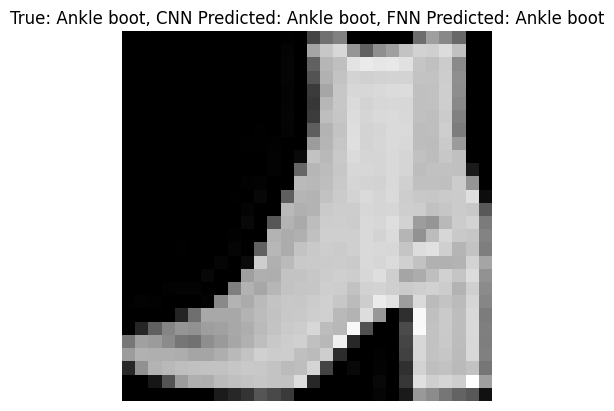

In [ ]:
# Display a sample prediction
for i in range(10):
    plt.imshow(np.squeeze(X_test[i]), cmap='gray')
    plt.axis('off')
    plt.title(f"True: {fashion_classes[y_test[i]]}, CNN Predicted: {fashion_classes[cnn_predicted_classes[i]]}, FNN Predicted: {fashion_classes[fnn_predicted_classes[i]]}")
    plt.show()

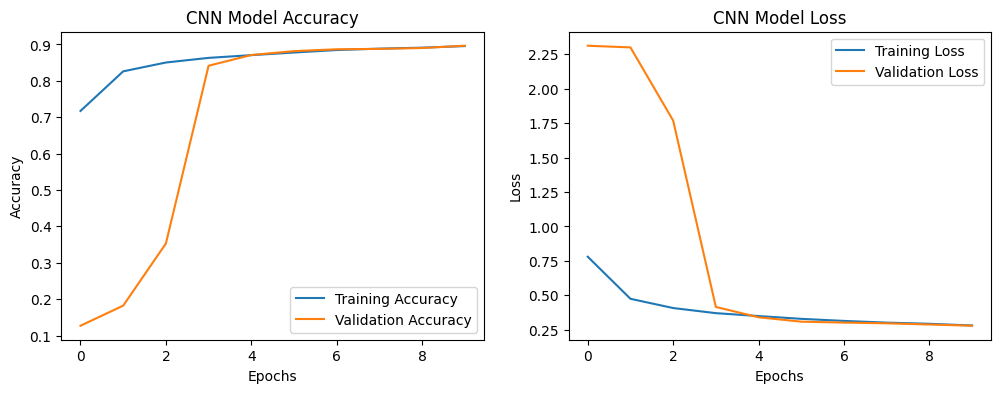

In [ ]:
plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history['accuracy'], label='Training Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('CNN Model Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['loss'], label='Training Loss')
plt.plot(cnn_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('CNN Model Loss')
plt.legend()

plt.show()


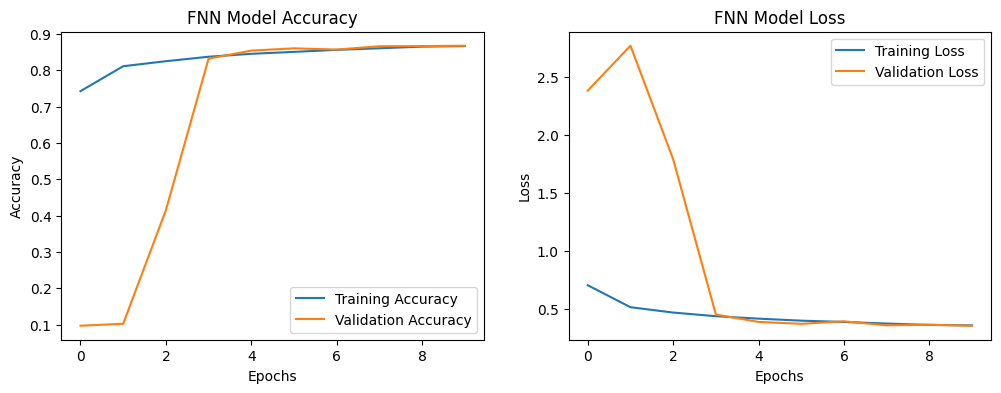

In [ ]:
# Plotting accuracy and loss curves for the FNN model
plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(fnn_history.history['accuracy'], label='Training Accuracy')
plt.plot(fnn_history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('FNN Model Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(fnn_history.history['loss'], label='Training Loss')
plt.plot(fnn_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('FNN Model Loss')
plt.legend()

plt.show()

<Figure size 1000x800 with 0 Axes>

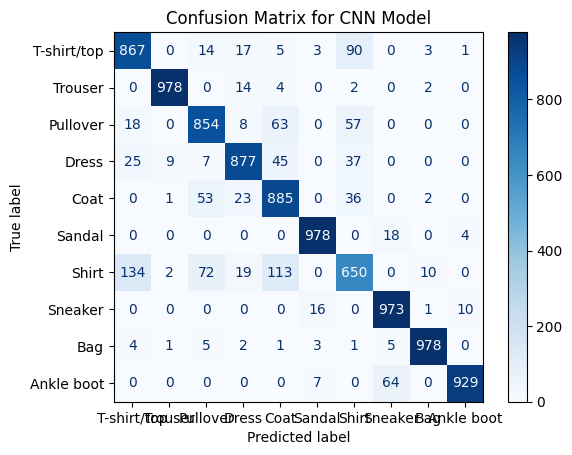

<Figure size 1000x800 with 0 Axes>

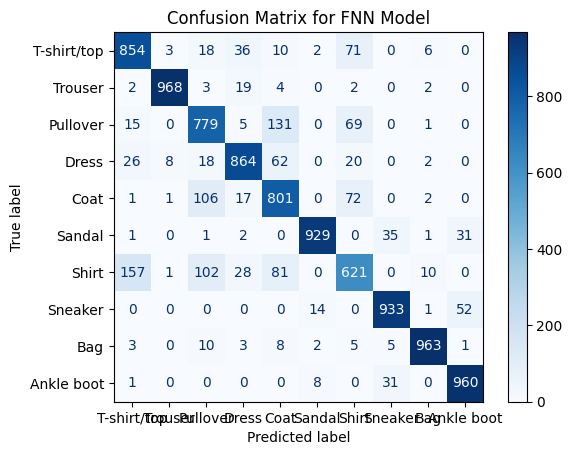

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix for CNN
cnn_cm = confusion_matrix(y_test, cnn_predicted_classes)
plt.figure(figsize=(10, 8))
ConfusionMatrixDisplay(cnn_cm, display_labels=list(fashion_classes.values())).plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix for CNN Model')
plt.show()

# Confusion Matrix for FNN
fnn_cm = confusion_matrix(y_test, fnn_predicted_classes)
plt.figure(figsize=(10, 8))
ConfusionMatrixDisplay(fnn_cm, display_labels=list(fashion_classes.values())).plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix for FNN Model')
plt.show()

In [ ]:
# Importing additional classifiers for comparison
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
knn_classifier = KNeighborsClassifier(n_neighbors=5)
svm_classifier = SVC(kernel='linear', probability=True)

# Train RandomForestClassifier
rf_classifier.fit(X_train_flat, y_train)
rf_predicted_classes = rf_classifier.predict(X_test_flat)
print("Classification Report for RandomForestClassifier:\n")
print(classification_report(y_test, rf_predicted_classes, target_names=list(fashion_classes.values())))

# Train KNeighborsClassifier
knn_classifier.fit(X_train_flat, y_train)
knn_predicted_classes = knn_classifier.predict(X_test_flat)
print("Classification Report for KNeighborsClassifier:\n")
print(classification_report(y_test, knn_predicted_classes, target_names=list(fashion_classes.values())))

# Train SVC
svm_classifier.fit(X_train_flat, y_train)
svm_predicted_classes = svm_classifier.predict(X_test_flat)
print("Classification Report for SVM Classifier:\n")
print(classification_report(y_test, svm_predicted_classes, target_names=list(fashion_classes.values())))


Classification Report for RandomForestClassifier:

              precision    recall  f1-score   support

 T-shirt/top       0.82      0.80      0.81      1000
     Trouser       0.99      0.95      0.97      1000
    Pullover       0.74      0.76      0.75      1000
       Dress       0.81      0.91      0.86      1000
        Coat       0.71      0.81      0.76      1000
      Sandal       0.91      0.96      0.93      1000
       Shirt       0.70      0.53      0.60      1000
     Sneaker       0.92      0.88      0.90      1000
         Bag       0.95      0.95      0.95      1000
  Ankle boot       0.94      0.94      0.94      1000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000

Classification Report for KNeighborsClassifier:

              precision    recall  f1-score   support

 T-shirt/top       0.77      0.83      0.80      1000
     Trouser       0.99      0.9